### 📁 Dataset Preparation and DataLoader Setup

This section of the notebook performs the following tasks:

---

#### ✅ 1. Copy Dataset
- Copies the dataset from the Kaggle input directory to the working directory.
- **Source**: `/kaggle/input/resnet-100/dataset_for_100_classes/resnet_dataset_top100`  
- **Destination**: `/kaggle/working/resnet_dataset`

---

#### 🔄 2. Define Image Transforms
- Defines separate transforms for `train` and `test` sets using `torchvision.transforms`.
- Applies:
  - `Resize` to (256, 256)
  - `ToTensor()`
  - `Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])`

---

#### 🗂 3. Create Datasets
- Uses `ImageFolder` to read images organized in class-based folders.
- Automatically labels images based on folder names for both `train` and `test` sets.

---

#### 🚚 4. Create DataLoaders
- Wraps datasets in `DataLoader` for efficient training and evaluation.
- Parameters:
  - `batch_size = 16`
  - `num_workers = 4`
  - `shuffle = True`

---

#### 📊 5. Print Dataset Statistics
- Total number of images in `train` and `test` sets.
- Total number of classes.
- Prints a class index-to-name mapping.


In [1]:
import shutil
import os

src_dataset = "/kaggle/input/resnet-100/dataset_for_100_classes/resnet_dataset_top100"
dst_dataset = "/kaggle/working/resnet_dataset"

# Copy dataset recursively to working directory
shutil.copytree(src_dataset, dst_dataset, dirs_exist_ok=True)

print("Dataset copied to working directory.")


Dataset copied to working directory.


In [2]:
import torch
import torchvision.transforms as transforms
from torchvision import datasets
import os

# Define a replacement for makeDefaultTransforms() that produces fixed-size images.
def makeDefaultTransforms():
    data_transforms = {
        'train': transforms.Compose([
            # Force all images to 256x256.
            transforms.Resize((256,256)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225])
        ]),
        'test': transforms.Compose([
            transforms.Resize((256,256)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225])
        ])
    }
    return data_transforms

# Set the root directory for data in Kaggle working directory.
data_dir = "/kaggle/working/resnet_dataset"
batch_size = 16
num_workers = 4

# Get data transforms using our defined function.
data_transforms = makeDefaultTransforms()

# Setup datasets and data loaders
image_datasets = {
    x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
    for x in ['train', 'test']
}
dataloaders = {
    x: torch.utils.data.DataLoader(image_datasets[x], batch_size=batch_size,
                                    shuffle=True, num_workers=num_workers)
    for x in ['train', 'test']
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'test']}
class_names = image_datasets['train'].classes

print('Number of data')
print('========================================')
for dataset in dataset_sizes.keys():
    print(dataset, ' size:: ', dataset_sizes[dataset], ' images')

print('')
print('Number of classes:: ', len(class_names))
print('========================================')
for i_class, class_name in enumerate(class_names):
    print(i_class, ':: ', class_name)


Number of data
train  size::  7108  images
test  size::  1787  images

Number of classes::  100
0 ::  Barn Swallow
1 ::  Bay breasted Warbler
2 ::  Black and white Warbler
3 ::  Black billed Cuckoo
4 ::  Black throated Blue Warbler
5 ::  Black throated Sparrow
6 ::  Blue Grosbeak
7 ::  Blue Jay
8 ::  Bobolink
9 ::  Bohemian Waxwing
10 ::  Bronzed Cowbird
11 ::  Brown Creeper
12 ::  Brown Pelican
13 ::  Brown Thrasher
14 ::  Canada Warbler
15 ::  Cape Glossy Starling
16 ::  Cape May Warbler
17 ::  Cardinal
18 ::  Carolina Wren
19 ::  Caspian Tern
20 ::  Cedar Waxwing
21 ::  Cerulean Warbler
22 ::  Chuck will Widow
23 ::  Clark Nutcracker
24 ::  Common Yellowthroat
25 ::  Eared Grebe
26 ::  Eastern Towhee
27 ::  European Goldfinch
28 ::  Evening Grosbeak
29 ::  Forsters Tern
30 ::  Fox Sparrow
31 ::  Geococcyx
32 ::  Golden winged Warbler
33 ::  Gray Kingbird
34 ::  Gray crowned Rosy Finch
35 ::  Green Jay
36 ::  Green Violetear
37 ::  Green tailed Towhee
38 ::  Harris Sparrow
39 ::  Hee

In [3]:
import torch

# Setup the device to run computations on GPUs
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Device::', device)


Device:: cuda


### 🧠 Model Initialization & Training with Checkpoints

This section performs the setup and training of a ResNet152 model for classification.

---

#### 🏗 1. Model Initialization
- **Model Used**: `ResNet152` from `torchvision.models`
- The model is instantiated **without pretrained weights**.
- Final fully connected layer is replaced to match the number of classes (`len(class_names)`).

---

#### 🔄 2. Loading Pretrained Weights
- Loads a custom `model_state_dict` from a previous training checkpoint:
  ```
  /kaggle/input/resnet-model-for-100/model_state_dict_epoch_15.pth
  ```
- Uses `torch.nn.DataParallel` to ensure compatibility with saved weights.
- Loads weights using `torch.load(..., weights_only=True)` (for security with PyTorch ≥ 2.0).

---

#### ⚙️ 3. Training Setup
- **Optimizer**: `AdamW` with learning rate `0.001`
- **Loss Function**: `CrossEntropyLoss`
- **Scheduler**: `StepLR` that decays LR every 7 epochs by a factor of 0.1
- Model is moved to GPU using:
  ```python
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  ```

---

#### 🏋️‍♂️ 4. Training with Checkpoints
- A custom function `train_model_with_checkpoints(...)` handles training and validation.
- For each epoch:
  - Sets model to `train` or `eval` mode
  - Uses `tqdm` for progress visualization
  - Computes loss and accuracy
  - Steps the learning rate scheduler (after training phase)
- Keeps track of:
  - `train_loss`, `train_acc`, `test_loss`, `test_acc`, and `epoch`

---

#### 💾 5. Saving Checkpoints
- Saves model checkpoints every **4 epochs**:
  ```python
  /kaggle/working/checkpoints/checkpoint_epoch_X.pth
  ```
- Each checkpoint contains:
  - `epoch`, `model_state_dict`, `optimizer_state_dict`, `scheduler_state_dict`, `history`

---

#### 🏁 Final Output
- Prints best validation accuracy achieved.
- Returns the **best model weights** and the **training history**.


In [5]:
import torch
import torchvision.models as models
from torch import nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR

PRETRAINED_SD_PATH = '/kaggle/input/resnet-model-for-100/model_state_dict_epoch_15.pth'

model_ft = models.resnet152(weights=None)

num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, len(class_names))

model_ft = torch.nn.DataParallel(model_ft)

state_dict = torch.load(PRETRAINED_SD_PATH, map_location='cpu', weights_only=True)
model_ft.load_state_dict(state_dict)

model_ft = model_ft.to(device)

optimizer_ft = AdamW(model_ft.parameters(), lr=0.001)
criterion    = nn.CrossEntropyLoss()
exp_lr_scheduler = StepLR(optimizer_ft, step_size=7, gamma=0.1)


In [6]:
working_dir    = "/kaggle/working"
checkpoint_dir = os.path.join(working_dir, "checkpoints")
os.makedirs(checkpoint_dir, exist_ok=True)

In [ ]:
import copy
import os
import torch
from tqdm import tqdm

def train_model_with_checkpoints(model, criterion, optimizer, scheduler, device, dataloaders, dataset_sizes, num_epochs, working_dir, checkpoint_dir):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {'epoch': [], 'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs-1}')
        print('-' * 10)
        
        # Each epoch has a training and validation phase
        for phase in ['train', 'test']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluation mode

            running_loss = 0.0
            running_corrects = 0

            # Wrap the dataloader with tqdm to show progress for the phase
            phase_dataloader = tqdm(dataloaders[phase], desc=f'{phase.capitalize()} Phase', leave=False)
            for inputs, labels in phase_dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                optimizer.zero_grad()
                
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                
                # Update progress bar with current loss
                phase_dataloader.set_postfix(loss=loss.item())
            
            if phase == 'train':
                scheduler.step()  # Step the scheduler after the training phase
            
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            
            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            
            # Record history
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['test_loss'].append(epoch_loss)
                history['test_acc'].append(epoch_acc.item())
        
        history['epoch'].append(epoch)
        
        # Update best model weights if validation accuracy improves.
        if epoch_acc > best_acc:
            best_acc = epoch_acc
            best_model_wts = copy.deepcopy(model.state_dict())
        
        # Save checkpoint every 4 epochs
        if epoch % 4 == 0:
            checkpoint_path = os.path.join(checkpoint_dir, f'checkpoint_epoch_{epoch}.pth')
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'history': history,
            }, checkpoint_path)
            print(f'Checkpoint saved to {checkpoint_path}\n')
    
    print('Training complete')
    print('Best val Acc: {:4f}'.format(best_acc))
    
    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model, history

model_ft, history = train_model_with_checkpoints(
    model=model_ft,
    criterion=criterion,
    optimizer=optimizer_ft,
    scheduler=exp_lr_scheduler,
    device=device,
    dataloaders=dataloaders,
    dataset_sizes=dataset_sizes,
    num_epochs=10,
    working_dir=working_dir,
    checkpoint_dir=checkpoint_dir
)


Epoch 0/9
----------


Train Loss: 1.5392 Acc: 0.5642


Test Loss: 1.8531 Acc: 0.5036
Checkpoint saved to /kaggle/working/checkpoints/checkpoint_epoch_0.pth

Epoch 1/9
----------


Train Loss: 1.3238 Acc: 0.6261


Test Loss: 1.7286 Acc: 0.5618
Epoch 2/9
----------


...

Test Loss: 0.7600 Acc: 0.7896
Epoch 8/9
----------


Train Loss: 0.1878 Acc: 0.9513


Test Loss: 0.7600 Acc: 0.8025
Checkpoint saved to /kaggle/working/checkpoints/checkpoint_epoch_8.pth

Epoch 9/9
----------


Train Loss: 0.1469 Acc: 0.9645


Test Loss: 0.7931 Acc: 0.7969
Training complete
Best val Acc: 0.802462


---

### 🖼️ Inference, Evaluation, and Class-wise Performance Analysis

---

#### 🎯 1. Random Test Inference
- Selects a random image from the **test dataset**.
- Applies preprocessing and runs inference using `model_ft`.
- Displays the image with the **true label** and **predicted label** using `IPython.display`.

---

#### 📦 2. Load Best Checkpoint
- Loads model weights from a specific checkpoint:
  ```
  /kaggle/working/checkpoints/checkpoint_epoch_8.pth
  ```
- Applies the loaded weights to `model_ft` and sets it to evaluation mode.

---

#### 📊 3. Evaluation Metrics
- Runs inference across the entire **test dataset**.
- Computes:
  - ✅ **Overall Accuracy**
  - 📃 **Classification Report** (Precision, Recall, F1-score for each class)
  - 📉 **Confusion Matrix**
- Saves:
  - `classification_report_epoch8.txt`
  - `confusion_matrix_epoch8.csv`
  - `confusion_matrix_epoch8.png` (visualized as a heatmap)

---

#### 📈 4. Class-wise Accuracy and Loss
- Loads test images from:
  ```
  /kaggle/working/resnet_dataset/test
  ```
- For each class:
  - Tracks total predictions, correct predictions, and cumulative loss.
  - Computes:
    - 🔍 **Accuracy** = correct / total
    - 💥 **Average Loss** per class
- Sorts and prints results by class accuracy in descending order.

---

#### 🧾 Example Output Format:
```
Class-wise Accuracy and Loss (Sorted by Accuracy)
==========================================================
001: 018 :: Airbus_A320                  | Accuracy: 98.21% | Loss: 0.0341
002: 057 :: F-16_Fighting_Falcon         | Accuracy: 97.56% | Loss: 0.0563
...
```

---

#### 💾 Outputs:
- 📁 `classification_report_epoch8.txt`
- 📁 `confusion_matrix_epoch8.csv`
- 🖼 `confusion_matrix_epoch8.png`


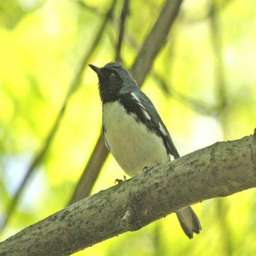

In [24]:
import random
import numpy as np
from PIL import Image
import torch
from IPython.display import display, HTML
import torchvision.transforms as transforms

test_dataset = image_datasets['test']
img_path, true_idx = random.choice(test_dataset.imgs)  
true_label = class_names[true_idx]

img_pil = Image.open(img_path).convert('RGB')
input_tensor = data_transforms['test'](img_pil).unsqueeze(0).to(device)

model_ft.eval()
with torch.no_grad():
    outputs = model_ft(input_tensor)
    pred_idx = outputs.argmax(dim=1).item()
    pred_label = class_names[pred_idx]

img_tensor = input_tensor.cpu().squeeze(0)           
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
img_np = img_tensor.permute(1, 2, 0).numpy()        
img_np = std * img_np + mean
img_np = np.clip(img_np, 0, 1)

# 5. Convert back to PIL and display
disp_img = Image.fromarray((img_np * 255).astype(np.uint8))

# Use IPython.display.display to show the image in Kaggle
display(HTML(f"<h3>True: {true_label} — Predicted: {pred_label}</h3>"))
display(disp_img)


In [ ]:
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the best checkpoint
checkpoint_path = '/kaggle/working/checkpoints/checkpoint_epoch_8.pth'
checkpoint = torch.load(checkpoint_path, map_location=device)
model_ft.load_state_dict(checkpoint['model_state_dict'])
model_ft.to(device)
model_ft.eval()

# 2. Gather predictions & labels on the test set
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model_ft(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 3. Compute accuracy
acc = accuracy_score(all_labels, all_preds)
print(f"Overall Accuracy: {acc:.4f}")

# 4. Classification report
report_str = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4
)
print("\nClassification Report:\n", report_str)

# Save classification report
with open('classification_report_epoch8.txt', 'w') as f:
    f.write(f"Overall Accuracy: {acc:.4f}\n\n")
    f.write(report_str)

# 5. Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
print("\nConfusion Matrix:\n", cm_df)

# Save confusion matrix CSV
cm_df.to_csv('confusion_matrix_epoch8.csv')

# 6. Plot & save confusion matrix heatmap
plt.figure(figsize=(12,10))
plt.imshow(cm, interpolation='nearest', aspect='auto')
plt.title('Confusion Matrix (Epoch 8 Best Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(ticks=range(len(class_names)), labels=class_names, rotation=90)
plt.yticks(ticks=range(len(class_names)), labels=class_names)
plt.colorbar()
plt.tight_layout()
plt.savefig('confusion_matrix_epoch8.png')
plt.show()

print("\n✅ Saved files for Epoch 8 best model:")
print(" - classification_report_epoch8.txt")
print(" - confusion_matrix_epoch8.csv")
print(" - confusion_matrix_epoch8.png")


<ipython-input-26-eff88e08ed62>:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)


Overall Accuracy: 0.8025

Classification Report:
                              precision    recall  f1-score   support

               Barn Swallow     0.9286    0.7222    0.8125        18
       Bay breasted Warbler     0.8333    0.8333    0.8333        18
    Black and white Warbler     0.9333    0.7778    0.8485        18
        Black billed Cuckoo     0.7619    0.8889    0.8205        18
Black throated Blue Warbler     0.8889    0.8889    0.8889        18
     Black throated Sparrow     0.7619    0.8889    0.8205        18
              Blue Grosbeak     0.8667    0.7222    0.7879        18
                   Blue Jay     0.8667    0.7222    0.7879        18
                   Bobolink     0.8824    0.8333    0.8571        18
           Bohemian Waxwing     0.7500    0.6667    0.7059        18
            Bronzed Cowbird     0.8571    1.0000    0.9231        18
              Brown Creeper     0.6000    0.8333    0.6977        18
              Brown Pelican     0.8667    0.7222    

In [13]:
import torch
import torch.nn as nn
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import os
import numpy as np

# Paths
test_dir = '/kaggle/working/resnet_dataset/test'
checkpoint_path = '/kaggle/working/models/checkpoints/checkpoint_epoch_15.pth'

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Transforms
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Dataset and DataLoader
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Per-class tracking
num_classes = len(class_names)
class_correct = [0 for _ in range(num_classes)]
class_total = [0 for _ in range(num_classes)]
class_loss = [0.0 for _ in range(num_classes)]

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model_ft(images)
        loss = criterion(outputs, labels)

        preds = outputs.argmax(dim=1)
        corrects = preds.eq(labels)

        for i in range(len(labels)):
            label = labels[i].item()
            class_correct[label] += corrects[i].item()
            class_total[label] += 1
            class_loss[label] += loss.item()


# Calculate accuracy and average loss
class_metrics = []
for i in range(num_classes):
    acc = class_correct[i] / class_total[i] if class_total[i] > 0 else 0
    avg_loss = class_loss[i] / class_total[i] if class_total[i] > 0 else 0
    class_metrics.append((i, test_dataset.classes[i], acc, avg_loss))

# Sort by accuracy
class_metrics.sort(key=lambda x: x[2], reverse=True)

# Print results
print("Class-wise Accuracy and Loss (Sorted by Accuracy)")
print("==========================================================")
for rank, (idx, name, acc, avg_loss) in enumerate(class_metrics, 1):
    print(f"{rank:03d}: {idx:03d} :: {name:30s} | Accuracy: {acc * 100:6.2f}% | Loss: {avg_loss:.4f}")


Class-wise Accuracy and Loss (Sorted by Accuracy)
001: 010 :: Bronzed Cowbird                | Accuracy: 100.00% | Loss: 0.6055
002: 052 :: Mallard                        | Accuracy: 100.00% | Loss: 0.4144
003: 053 :: Myrtle Warbler                 | Accuracy: 100.00% | Loss: 0.4708
004: 061 :: Parakeet Auklet                | Accuracy: 100.00% | Loss: 0.7188
005: 067 :: Prothonotary Warbler           | Accuracy: 100.00% | Loss: 0.4658
006: 081 :: Spotted Catbird                | Accuracy: 100.00% | Loss: 0.5208
007: 021 :: Cerulean Warbler               | Accuracy:  94.44% | Loss: 0.5965
008: 039 :: Heermann Gull                  | Accuracy:  94.44% | Loss: 0.8092
009: 044 :: Horned Lark                    | Accuracy:  94.44% | Loss: 0.5267
010: 072 :: Red winged Blackbird           | Accuracy:  94.44% | Loss: 0.4371
011: 092 :: White breasted Kingfisher      | Accuracy:  94.44% | Loss: 0.4688
012: 098 :: Yellow headed Blackbird        | Accuracy:  94.44% | Loss: 0.5654
013: 003 :: Bl

In [27]:
import torch

# Path to the full checkpoint
checkpoint_path = '/kaggle/working/checkpoints/checkpoint_epoch_8.pth'

# Load the checkpoint (only weights, safe loading)
checkpoint = torch.load(checkpoint_path, map_location='cpu')

# Extract the model state dict
model_state_dict = checkpoint['model_state_dict']

# Save just the model_state_dict for later use
output_path = '/kaggle/working/model_state_dict_best.pth'
torch.save(model_state_dict, output_path)

print(f'Model state dict saved to {output_path}')


<ipython-input-27-4f597796d1ec>:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location='cpu')


Model state dict saved to /kaggle/working/model_state_dict_best.pth
